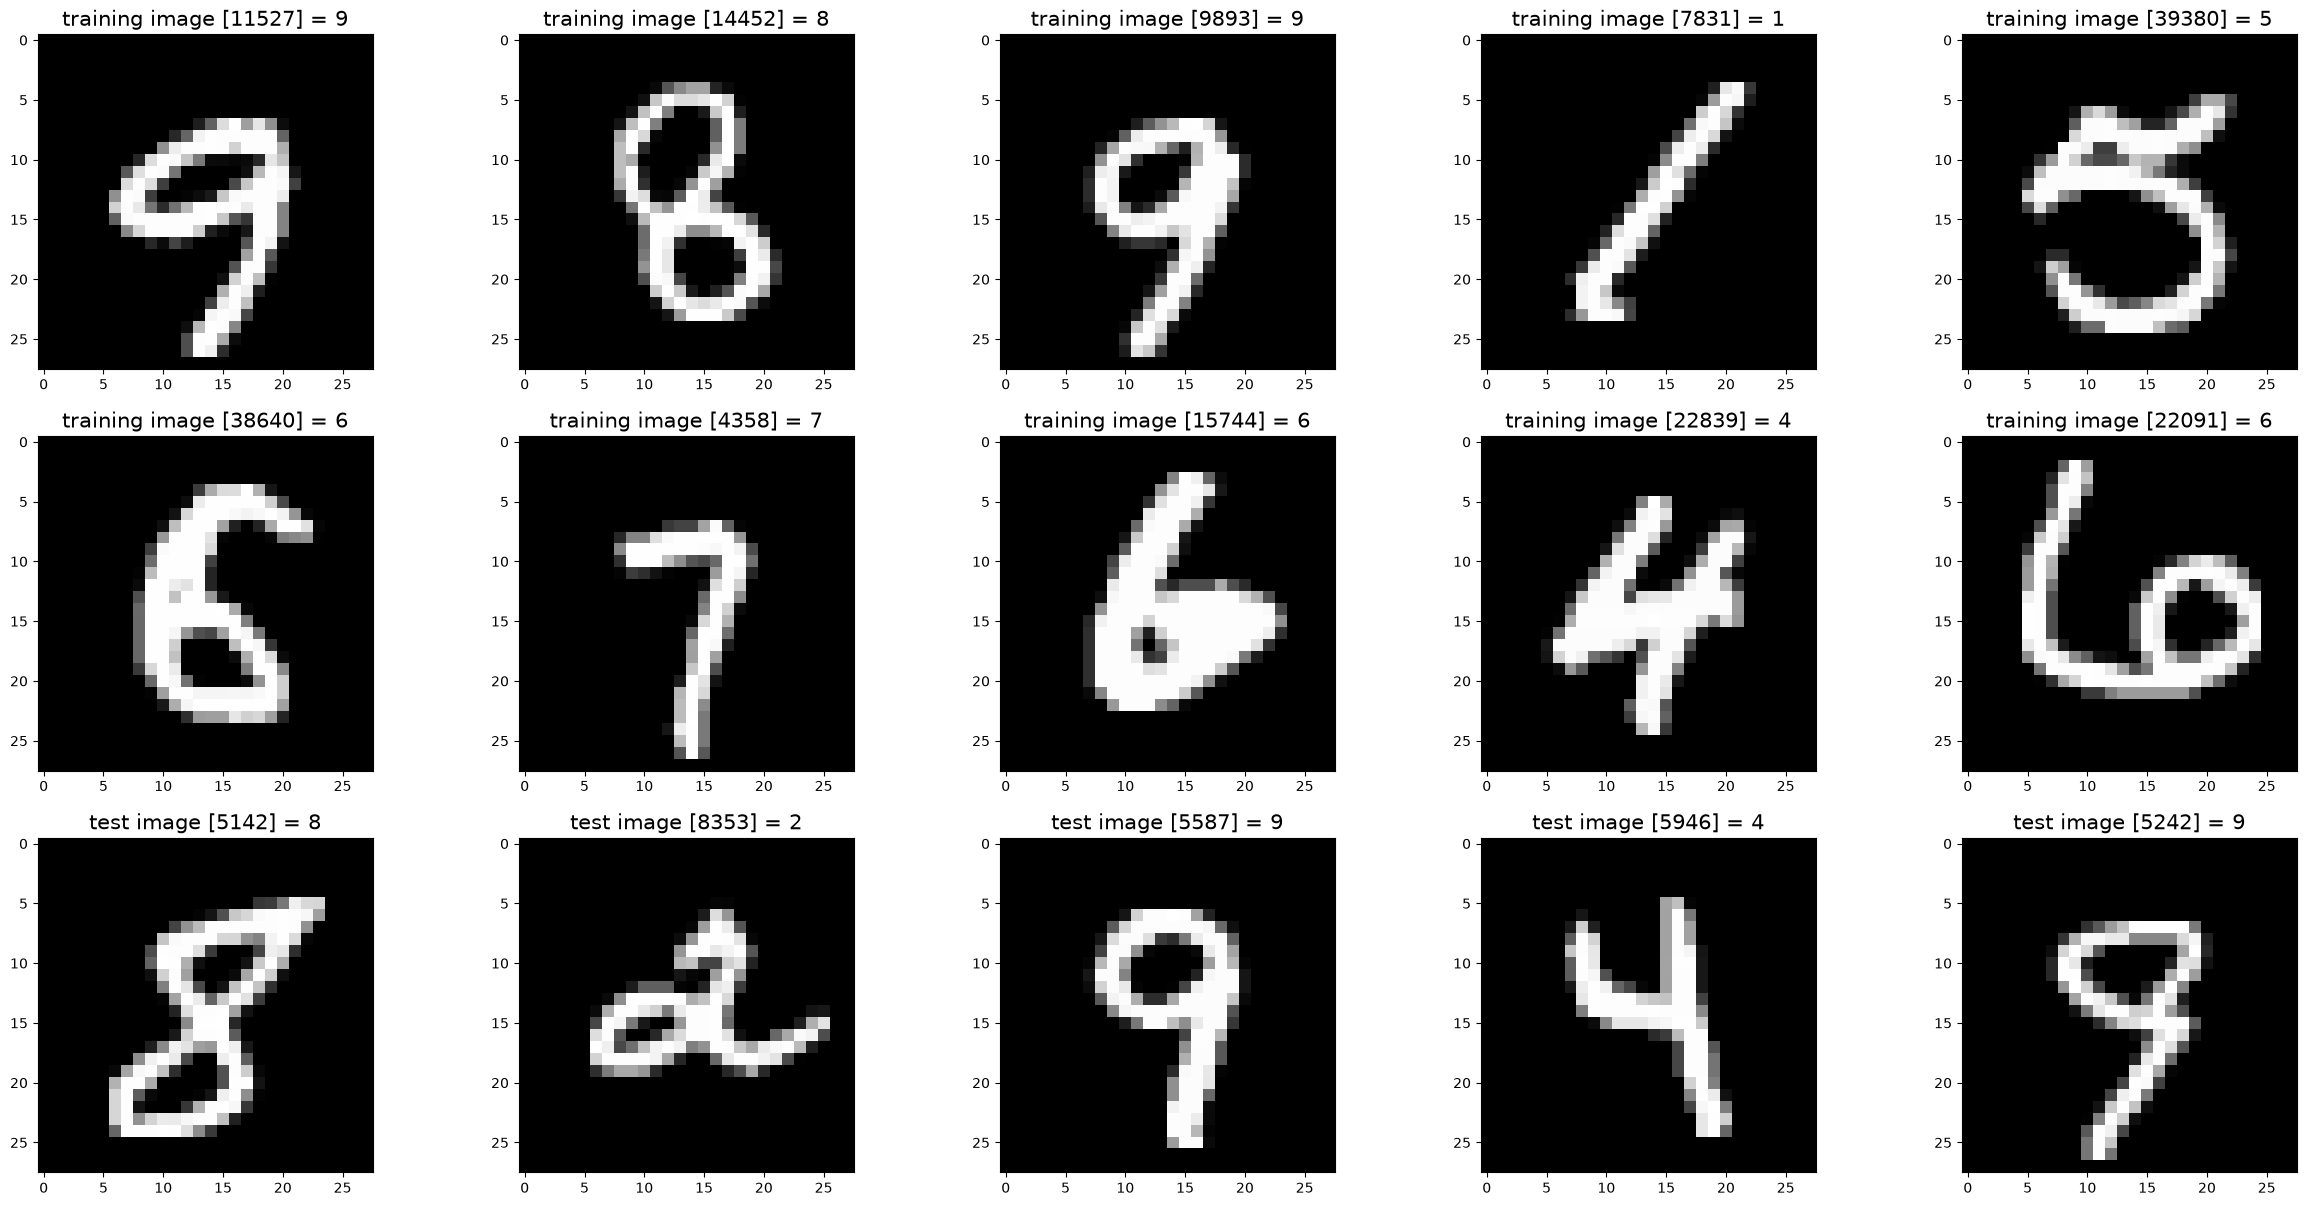

In [1]:
#
# This is a sample Notebook to demonstrate how to read "MNIST Dataset"
#
import numpy as np # linear algebra
import struct
from array import array
from os.path  import join

#
# MNIST Data Loader Class
#
class MnistDataloader(object):
    def __init__(self, training_images_filepath,training_labels_filepath,
                 test_images_filepath, test_labels_filepath):
        self.training_images_filepath = training_images_filepath
        self.training_labels_filepath = training_labels_filepath
        self.test_images_filepath = test_images_filepath
        self.test_labels_filepath = test_labels_filepath
    
    def read_images_labels(self, images_filepath, labels_filepath):        
        labels = []
        with open(labels_filepath, 'rb') as file:
            magic, size = struct.unpack(">II", file.read(8))
            if magic != 2049:
                raise ValueError('Magic number mismatch, expected 2049, got {}'.format(magic))
            labels = array("B", file.read())        
        
        with open(images_filepath, 'rb') as file:
            magic, size, rows, cols = struct.unpack(">IIII", file.read(16))
            if magic != 2051:
                raise ValueError('Magic number mismatch, expected 2051, got {}'.format(magic))
            image_data = array("B", file.read())        
        images = []
        flattened_images = []
        for i in range(size):
            images.append([0] * rows * cols)
            flattened_images.append([0]*rows*cols)
        for i in range(size):
            img = np.array(image_data[i * rows * cols:(i + 1) * rows * cols])
            flt_img = img.copy()
            img = img.reshape(28, 28)
            flattened_images[i]            
            images[i][:] = img            
            flattened_images[i][:] = flt_img
            
        return flattened_images, images, labels
            
    def load_data(self):
        x_train_flat, x_train, y_train = self.read_images_labels(self.training_images_filepath, self.training_labels_filepath)
        x_test_flat, x_test, y_test = self.read_images_labels(self.test_images_filepath, self.test_labels_filepath)
        return (x_train_flat, x_train, y_train),(x_test_flat, x_test, y_test)        

#
# Verify Reading Dataset via MnistDataloader class
#
import random
import matplotlib.pyplot as plt

#
# Set file paths based on added MNIST Datasets
#
input_path = './archive'
training_images_filepath = join(input_path, 'train-images-idx3-ubyte/train-images-idx3-ubyte')
training_labels_filepath = join(input_path, 'train-labels-idx1-ubyte/train-labels-idx1-ubyte')
test_images_filepath = join(input_path, 't10k-images-idx3-ubyte/t10k-images-idx3-ubyte')
test_labels_filepath = join(input_path, 't10k-labels-idx1-ubyte/t10k-labels-idx1-ubyte')

#
# Helper function to show a list of images with their relating titles
#
def show_images(images, title_texts):
    cols = 5
    rows = int(len(images)/cols) + 1
    plt.figure(figsize=(30,20))
    index = 1    
    for x in zip(images, title_texts):        
        image = x[0]        
        title_text = x[1]
        plt.subplot(rows, cols, index)        
        plt.imshow(image, cmap=plt.cm.gray)
        if (title_text != ''):
            plt.title(title_text, fontsize = 15);        
        index += 1

#
# Load MINST dataset
#
mnist_dataloader = MnistDataloader(training_images_filepath, training_labels_filepath, test_images_filepath, test_labels_filepath)
(x_train_flat, x_train, y_train), (x_test_flat, x_test, y_test) = mnist_dataloader.load_data()

#
# Show some random training and test images 
#
images_2_show = []
titles_2_show = []
for i in range(0, 10):
    r = random.randint(1, 60000)
    images_2_show.append(x_train[r])
    titles_2_show.append('training image [' + str(r) + '] = ' + str(y_train[r]))    

for i in range(0, 5):
    r = random.randint(1, 10000)
    images_2_show.append(x_test[r])        
    titles_2_show.append('test image [' + str(r) + '] = ' + str(y_test[r]))    

show_images(images_2_show, titles_2_show)


np_x_train_flat = np.array(x_train_flat)
int_y_train = np.array([int(i) for i in y_train])

np_x_test_flat = np.array(x_test_flat)
int_y_test = np.array([int(i) for i in y_test])

In [2]:
import math
import numpy as np

activations = []
weighted_sums = []
beta_1 = 0.90
beta_2 = 0.999
learning_rate = 0.001
moment_1_history = {}
moment_2_history = {}
epsilon = 10**-13

In [3]:
def sparse_categorical_crossentropy(prediction_probabilities_map, true_class):
    true_class_prediction = prediction_probabilities_map.get(true_class, 0)
    return -1*(math.log(true_class_prediction))

In [4]:
def relu(pred):
    return max(0,pred)

vectorized_relu = np.vectorize(relu)

In [5]:
def softmax(output_layer_output):
    max_per_sample = np.array([[max(sample_output) for i in range(len(sample_output))] for sample_output in output_layer_output])
    new_output_layer = output_layer_output - max_per_sample
    numerator = np.exp(new_output_layer)
    
    result = numerator/np.sum(numerator,axis=1, keepdims=True)
    
    return result


In [6]:
def softmax_sparse_categorical_crossentropy_gradient(logits_prediction_arr, true_class_idx):
    for i in range(len(logits_prediction_arr)):
        logits_prediction_arr[i][true_class_idx[i]]-=1
    return logits_prediction_arr

In [7]:
def relu_derivative(neurons_weighted_sum):
    return 1 if neurons_weighted_sum>0 else 0
vectorized_relu_derivative = np.vectorize(relu_derivative)

In [ ]:
def hidden_layer_backprop_gradients_for_layer(curr_pre_activations, next_layers_error_gradients, next_layers_weights):
    derivatives_of_curr_activations = (curr_pre_activations > 0).astype(float) # relu derivative to Z
    delta_array = np.array(next_layers_error_gradients) @ next_layers_weights.T
    delta_array = delta_array * derivatives_of_curr_activations
    return delta_array


In [9]:
def adam_optimizer(curr_weights, curr_gradients, iter, layer):
    moment_1_curr = (beta_1*(moment_1_history.get(layer,np.zeros(curr_weights.shape)))) + (1-beta_1) * curr_gradients
    moment_1_history[layer] = moment_1_curr

    hat_moment_1 = moment_1_curr/(1-beta_1**iter)

    moment_2_curr = beta_2*(moment_2_history.get(layer,np.zeros(curr_weights.shape))) + (1-beta_2) * curr_gradients**2
    moment_2_history[layer] = moment_2_curr

    hat_moment_2 = moment_2_curr/(1-beta_2**iter)

    new_weights = curr_weights - ((learning_rate/(np.sqrt(hat_moment_2)+epsilon)) * hat_moment_1)

    return new_weights

In [10]:
def forward_propagation(input_layer,weights, biases):
    global activations, weighted_sums
    
    input_matrix = input_layer
    prev_activations = input_matrix
    prediction = None
    for index in range(len(weights)):
        curr_weights = weights[index]
        weighted_sum = prev_activations @ curr_weights
        weighted_sums.append(weighted_sum)
        bias_added_weights = weighted_sum + biases[index]
        if index < len(weights)-1:
            prev_activations = vectorized_relu(bias_added_weights)
            activations.append(prev_activations)
        else:
            activations.append(bias_added_weights)
            prediction = softmax(bias_added_weights)
            
    return prediction
        
        





In [ ]:
def backward_propagation(layer_weights, layer_biases, prediction_array, batch_true_labels, time_step):

    global activations, weighted_sums
    
    # backprop for output layer

    output_layer_error_gradients = softmax_sparse_categorical_crossentropy_gradient(prediction_array,batch_true_labels)
    print("output_layer_error_gradients", output_layer_error_gradients.shape, output_layer_error_gradients)
    output_layer_weights_change = activations[-2].T @ output_layer_error_gradients
    # adam_optimized_output_layer_weights_change = adam_optimizer(layer_weights[-1],output_layer_weights_change,time_step,len(layer_weights)-1)


    # adam_optimized_weights_change_for_layers = {}

    # adam_optimized_weights_change_for_layers[len(layer_weights)-1] = adam_optimized_output_layer_weights_change

    errors_for_backprop = {
        len(layer_weights)-1:output_layer_weights_change
    }

    # backprop for the rest

    for l in range(len(layer_weights)-2,-1,-1):
        delta_j_arr = hidden_layer_backprop_gradients_for_layer(weighted_sums[l],errors_for_backprop[l+1],layer_weights[l+1])
        errors_for_backprop[l] = delta_j_arr
    
    #apply adam

    for l in range(1,len(layer_weights)-1):
        layer_changes = activations[l-1].T @ errors_for_backprop[l]
        adam_optimized_changes = adam_optimizer(layer_weights[l],layer_changes,time_step,l)
        layer_weights -= adam_optimized_changes






In [ ]:
def main_loop():

    rng = np.random.default_rng()
    # Define your desired custom range [low, high)
    low = -0.5
    high = 0.5

    layer_sizes = [784, 128, 64, 32, 10]

    layer_weights = []


    layer_biases = []

    # Xavier Initialization 
    for i in range(len(layer_sizes)-1):
        n_in = layer_sizes[i]
        n_out = layer_sizes[i+1]
        limit = np.sqrt(6/(n_in+n_out))
        weights = rng.uniform(-limit,limit,size=(n_in,n_out))
        biases = np.zeros((1,n_out))
        layer_weights.append(weights)
        layer_biases.append(biases)

    epochs = 10

    global activations, weighted_sums, np_x_train_flat, int_y_train
    train_data_size = len(np_x_train_flat)
    batch_data_size = 32

    iters_per_batch = train_data_size // batch_data_size
    batch_iter = 0
    for i in range(epochs):
        for j in range(iters_per_batch):
            activations = []
            weighted_sums = []
            batch_inputs = np_x_train_flat[batch_iter:batch_iter+batch_data_size]
            batch_true_labels = int_y_train[batch_iter:batch_iter+batch_data_size]

            prediction_array = forward_propagation(batch_inputs, layer_weights, layer_biases)
            
            time_step = i*j
            backward_propagation(layer_weights, layer_biases, prediction_array, batch_true_labels, time_step)
            batch_iter += batch_data_size
    
    np.savez("nn_model.npz", weights = layer_weights, biases = layer_biases)
    


main_loop()


output_layer_error_gradients (32, 10) [[ 4.21285488e-024  2.54101618e-072  4.03763770e-099  9.40708126e-046
   1.00000000e+000 -1.00000000e+000  7.58293913e-087  2.85516583e-074
   4.01388541e-030  2.66695528e-086]
 [-1.00000000e+000  6.42433596e-067  6.51107495e-054  6.44268649e-027
   1.00000000e+000  2.39471581e-044  1.82912978e-046  6.39064078e-036
   3.16146043e-018  1.25176258e-048]
 [ 2.48094027e-033  6.83483937e-090  5.54464275e-066  1.76831776e-028
   0.00000000e+000  3.86217591e-069  2.12398684e-070  3.09846721e-047
   1.18162671e-035  5.13840432e-064]
 [ 8.45453720e-014 -1.00000000e+000  3.42028187e-045  9.66119382e-010
   9.99999999e-001  3.97789739e-022  8.87776898e-061  1.12640327e-041
   5.37182680e-018  1.08530140e-043]
 [ 1.43936960e-035  1.13685866e-064  8.97214399e-065  9.06509605e-021
   1.00000000e+000  1.04077611e-026  1.00256929e-057  2.38727849e-054
   8.68451135e-026 -1.00000000e+000]
 [ 3.82211639e-047  6.14727271e-054 -1.00000000e+000  1.91092158e-043
   9.89

In [ ]:
data = np.load('nn_model.npz')
loaded_w = data['weights']
loaded_b = data['biases']